# Model & Marker Normalization

In the previous tutorial, we used the rainbow beads to calibrate the flow cytometer. We will now deal with the remaining staining differences by normalizing the markers.

- include export to .fcs?

In [1]:
import numpy as np
import pandas as pd
import anndata
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import PIL

#import cytovanni

import sys
local_path = os.path.expanduser("~/cytovanni_publish/Cytovanni/src")
if local_path not in sys.path:
    sys.path.insert(0, local_path)
import cytovanni
cytovanni.__version__

'1.1.0'

In [6]:
raw_data_path = os.path.expanduser("~/Cytovanni/data/example_fixed-spectra/")
data_path = os.path.expanduser("~/Cytovanni/docs/tutorials/integration_fixed-spectra/")

We strongly suggest using a GPU for speedup. Our model can also be fit without a GPU, and torch will use all available CPU cores. However, it would need more than 80 CPU cores to achieve the same speed as a reasonable GPU, so we strongly suggest running it on a machine with GPU support.

In [3]:
import torch
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(device)

cuda:0


Here, we use a small version of our A3 configuration with 21 instead of the full 23 fluorescence channels.

In [4]:
cytoconfig = cytovanni.utils.CytometerConfiguration_A3small()

## Data

First, we load all the reference samples after rainbow calibration. Here, the samples are clean enough that we do not need any additional gating.

In [7]:
folder = os.path.join(data_path, "ref", "data_rainbow_calibrated")
files = sorted(list(filter(lambda x: x.endswith(".fcs"), os.listdir(folder))))
adatas = []
for file in files:
    adata = cytovanni.io.readfcs_sample(os.path.join(folder, file), cytoconfig, gates=[])
    adata.uns["date"] = file.replace(".fcs","")
    adata.obs["date"] = file.replace(".fcs","")
    # set sample type, i.e. aliquots of the same sample should have the same name here
    adata.uns["sample"] = "Ref"
    adatas.append(adata)

We then use the single stain spectra to do the unmixing.

In [8]:
panel_spectra = pd.read_table(os.path.join(data_path, "ref", "panel_spectra_calibrated.csv"), sep=",", index_col=0)

for ad in adatas:
    ad.obsm["unmx"] = cytovanni.utils.apply_unmixing_lstsq(panel_spectra, ad.to_df(layer="raw"))
    ad.obsm["unmx_ash"] = cytovanni.utils.apply_arcsinh(ad.obsm["unmx"], 1500)

adata = cytovanni.utils.anndata_concat(adatas, make_unique=True, permute=True)

### Remaining Batch Effect

Even after the cytometer has been calibrated, we still see some batch effects in the marker abundances. We will split the markers into those where we can see a clear positive population, and those where we don't.

In [9]:
markers = list(panel_spectra.index)
markers_normalize = ['BV510', 'BV605', 'BB515', 'BUV396', 'BUV805', 'APC', 'APC-R700', 'APC-H7', 'BYG670']
markers_leave = [m for m in markers if not m in markers_normalize]

The ones with clear positive populations can be normalized using the reference samples.

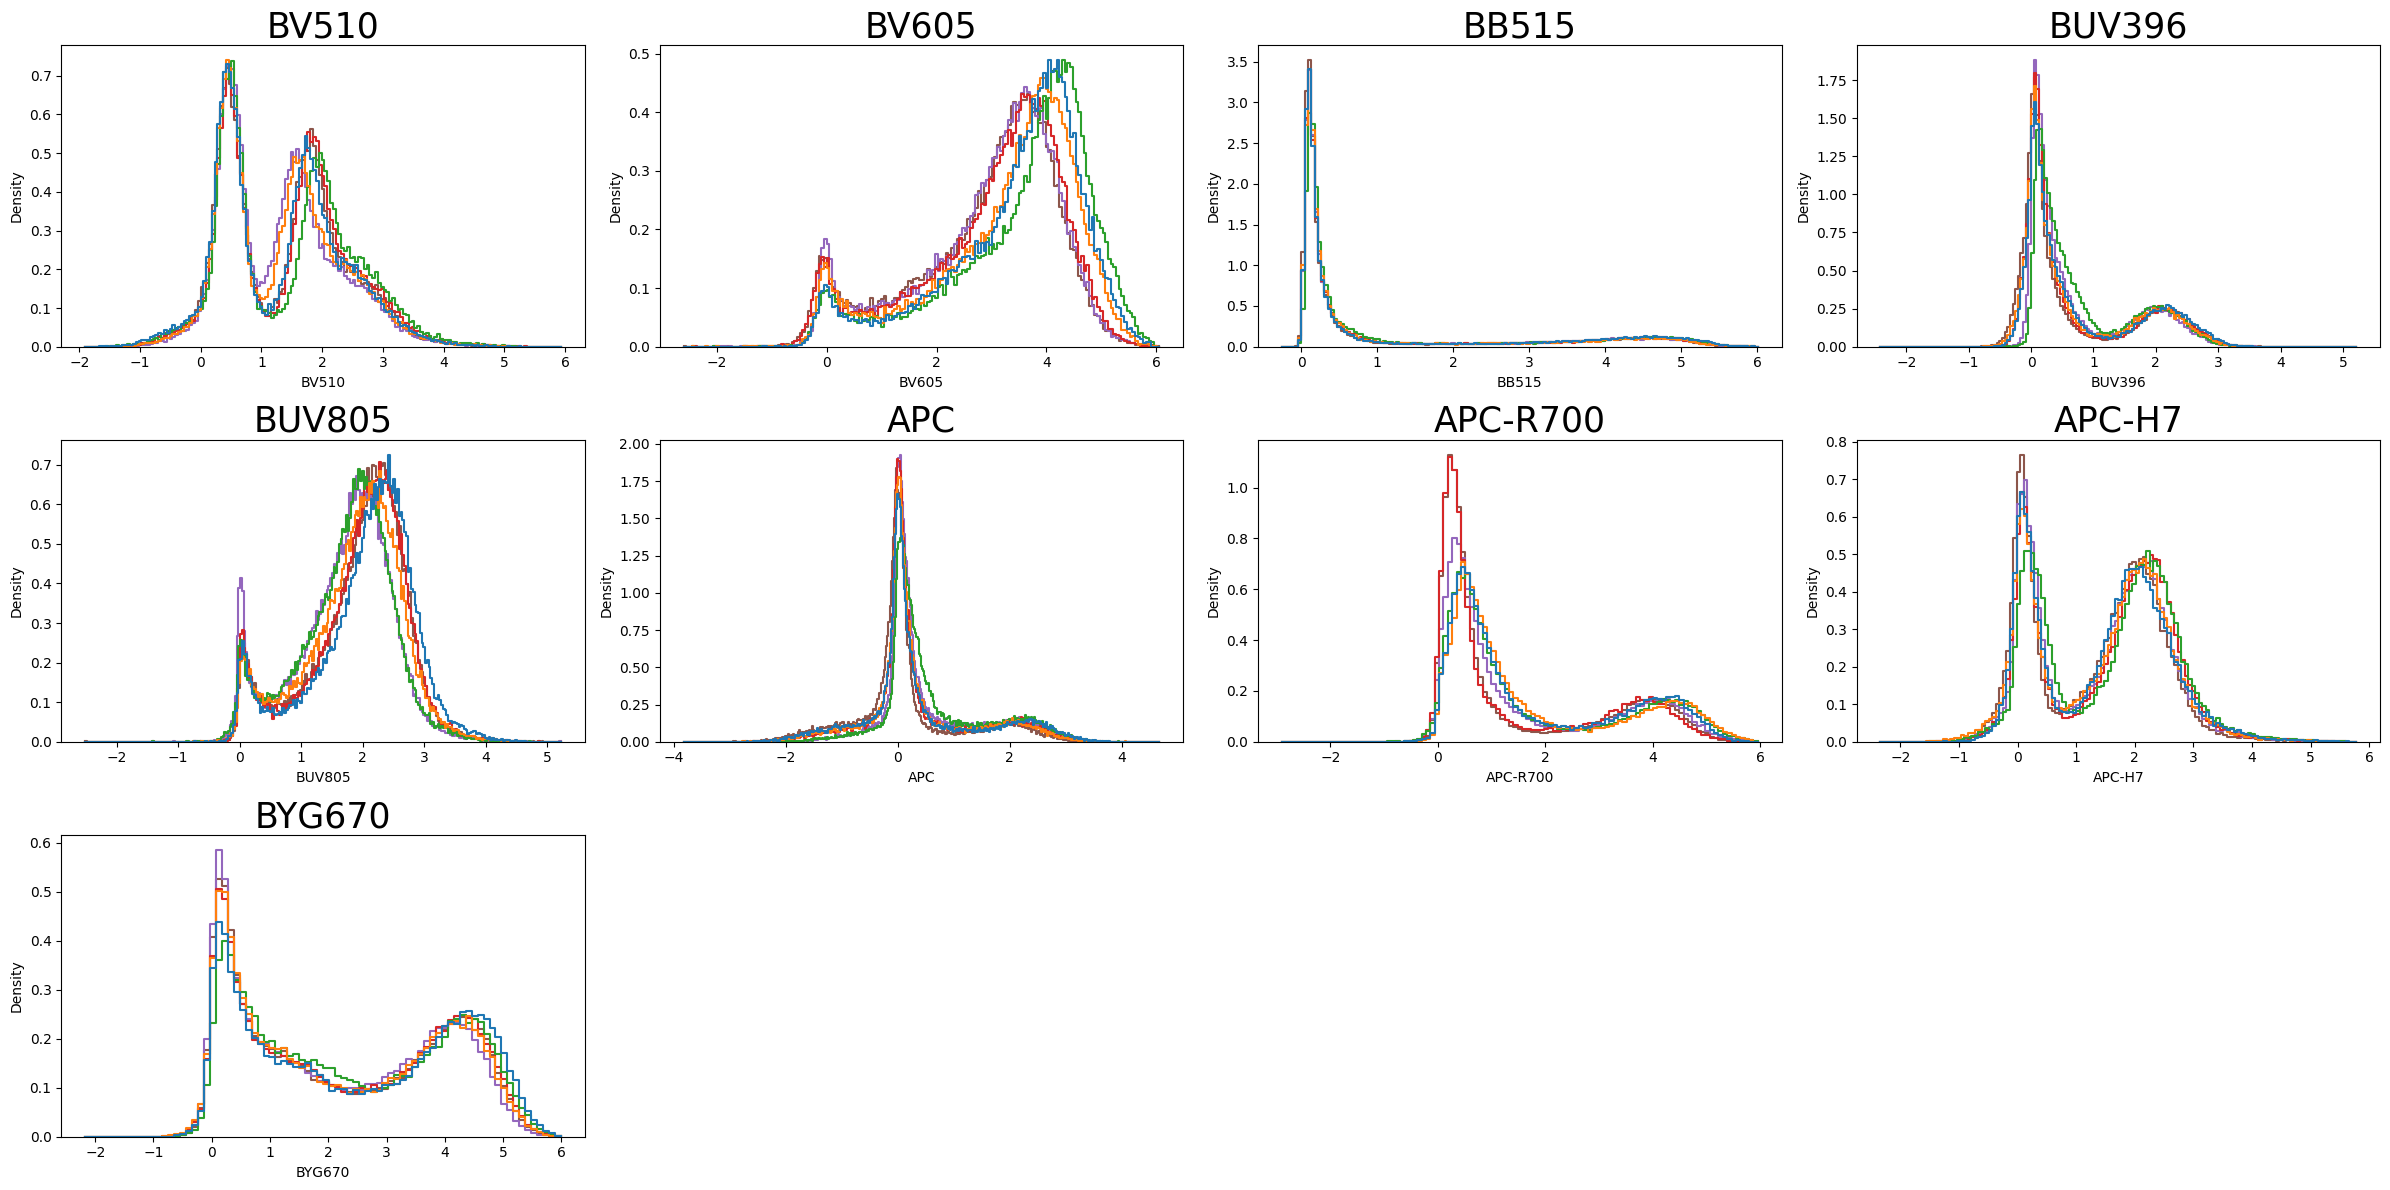

In [10]:
fig, ax = cytovanni.utils.unrolled_subplots(len(markers_normalize))
for i, key in enumerate(markers_normalize):
    sns.histplot(x=adata.obsm["unmx_ash"][key], hue=adata.obs["date"],
                    hue_order=sorted(adata.obs["date"].unique()), ax=ax[i], fill=False, element="step", legend=False, stat="density", common_norm=False)
    ax[i].set_title(key, size=25)
fig.tight_layout()

The ones where there is not a sufficient number of positive cells in the reference samples cannot be normalized using the reference sample. For this, we would either need a better reference sample that contains populations with all markers, or other overlapping samples that contain the missing markers. Also note that the precise position of the negative population is often determined by slight unmixing errors, which could be improved by slightly adjusting the dye spectra for every batch. However, as we do not have enough single stain measurements for this dataset, we will not attempt this here and instead refer to the tutorial that uses a larger dataset.

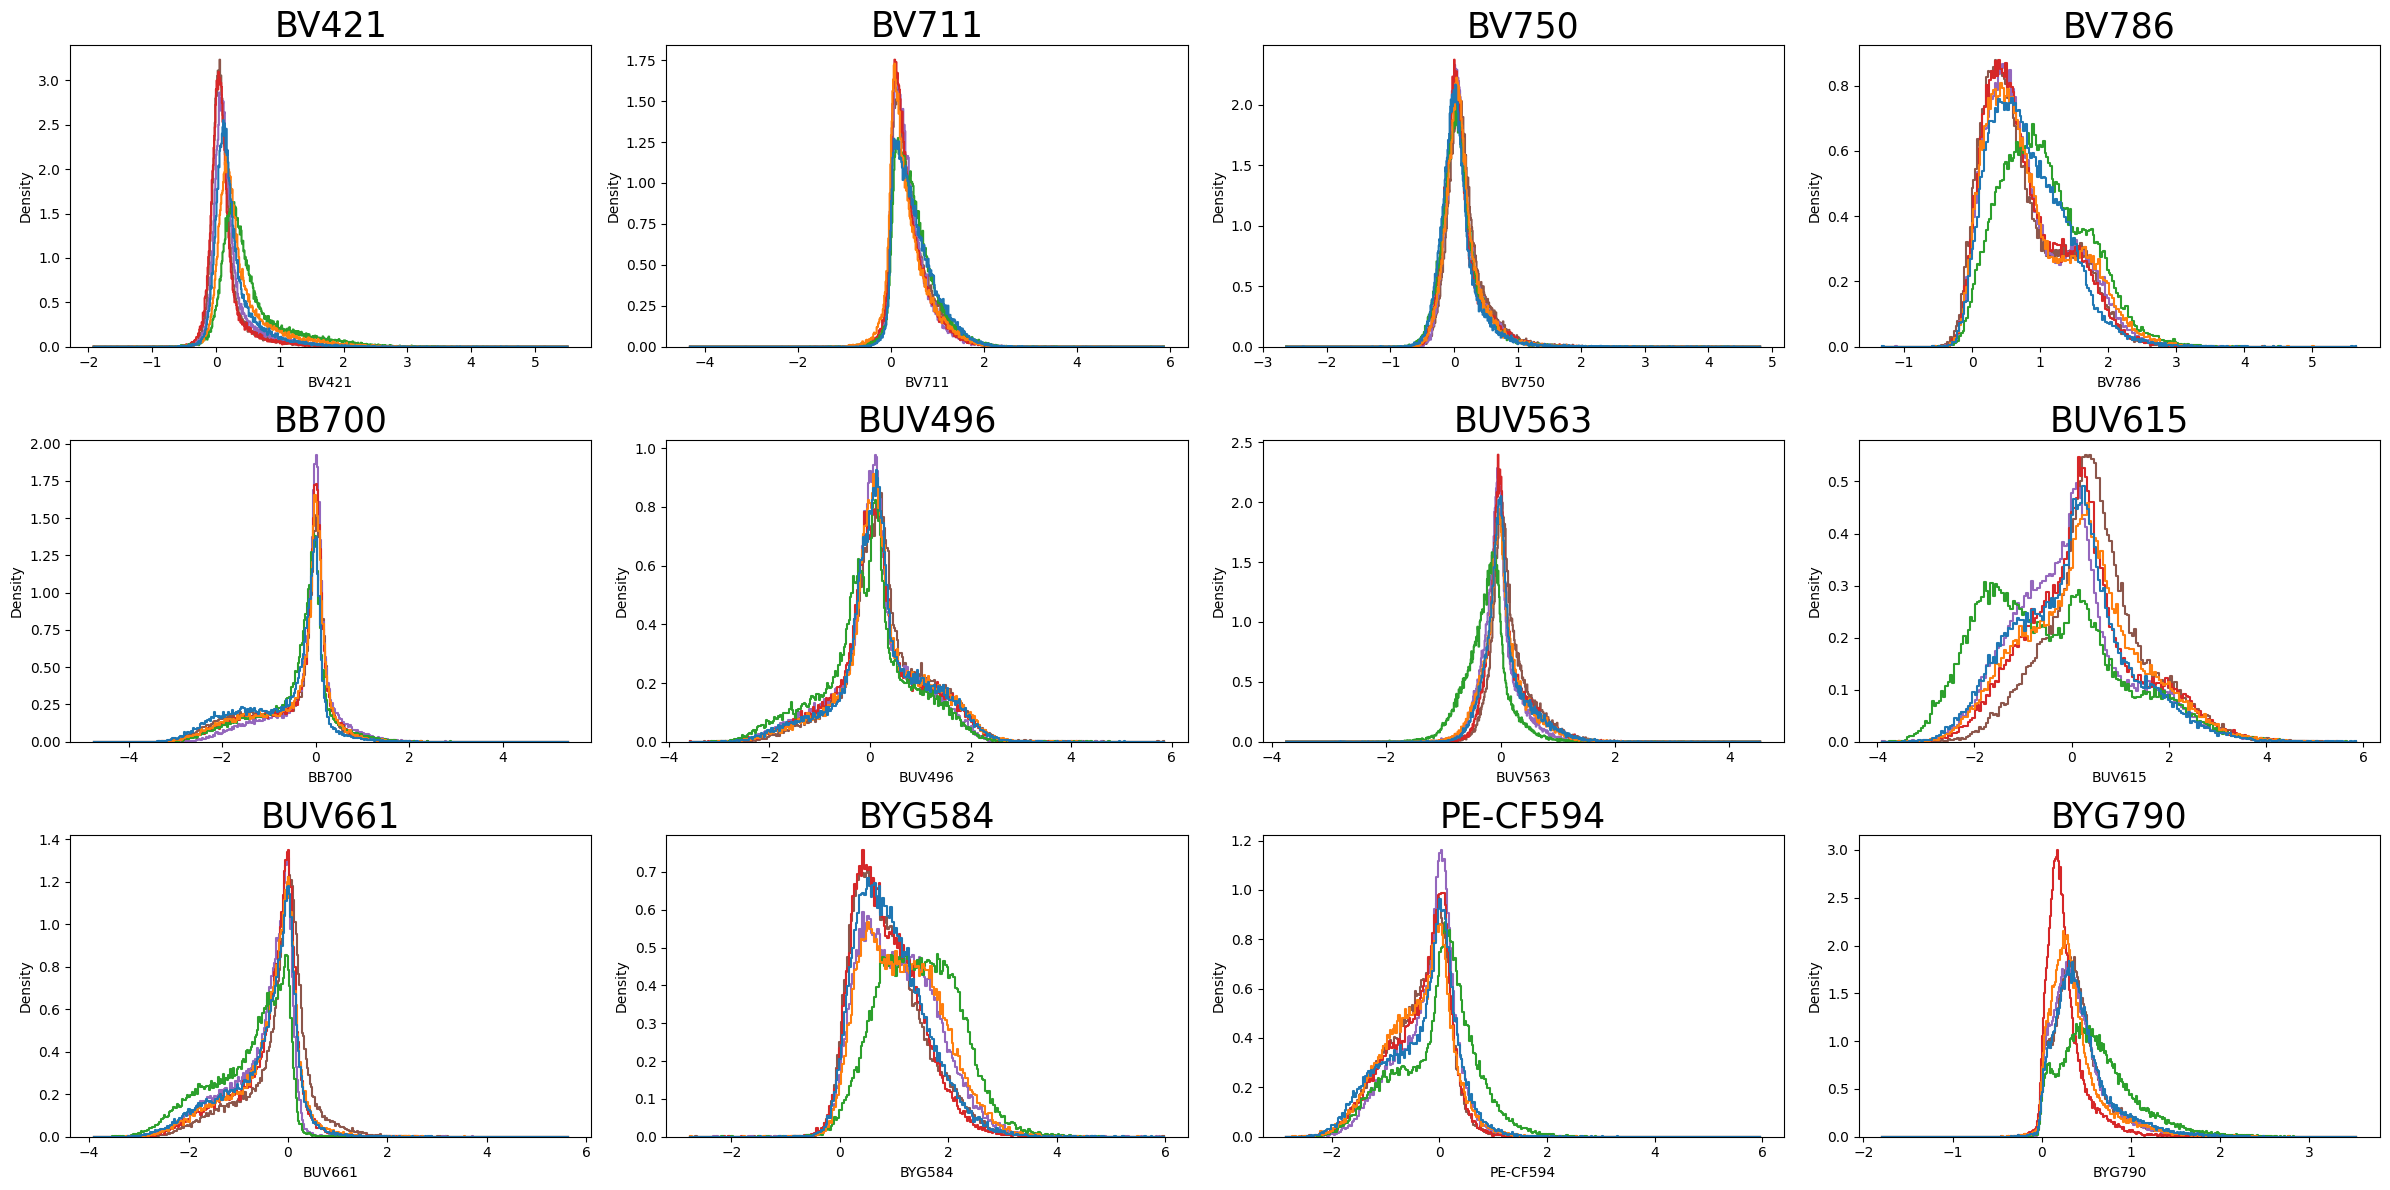

In [11]:
fig, ax = cytovanni.utils.unrolled_subplots(len(markers_leave))
for i, key in enumerate(markers_leave):
    sns.histplot(x=adata.obsm["unmx_ash"][key], hue=adata.obs["date"],
                    hue_order=sorted(adata.obs["date"].unique()), ax=ax[i], fill=False, element="step", legend=False, stat="density", common_norm=False)
    ax[i].set_title(key, size=25)
fig.tight_layout()

## Fit Marker Normalization

We first need to set which markers we want to scale:

In [12]:
markers = list(panel_spectra.index)
markers_normalize = ['BV510', 'BV605', 'BB515', 'BUV396', 'BUV805', 'APC', 'APC-R700', 'APC-H7', 'BYG670']

scale_markers = pd.Series(False, index=panel_spectra.index)
scale_markers.loc[markers_normalize] = True
scale_markers

BV421       False
BV510        True
BV605        True
BV711       False
BV750       False
BV786       False
BB515        True
BB700       False
BUV396       True
BUV496      False
BUV563      False
BUV615      False
BUV661      False
BUV805       True
APC          True
APC-R700     True
APC-H7       True
BYG584      False
PE-CF594    False
BYG670       True
BYG790      False
dtype: bool

We then set the batch label encoder, using .uns["date"] from the adatas:

In [13]:
moe = cytovanni.ref.MultiOrdinalEncoder.from_adatas(adatas, keys_batch=["date"])
moe.transform_ad(adatas[0])

{'date': tensor([0])}

While this isn't necessary, we also set one of the batches to be the integration anchor, i.e. all markers will be normalized to match this batch.

In contrast to the model where panel embeddings are also fit, here this simply means rescaling all factors after the fit is done.

In [14]:
anchors = {"date":'RF_12_11_2021'}
anchor_bidx = moe.transform_dict_simple(anchors)
anchor_bidx

{'date': np.int64(0)}

Now we prepare the dataset for the fit:

In [15]:
dataset = cytovanni.ref.SampleOverlapDataset(
        # the set of adatas to use
        adatas,
        # the batch encoder
        moe,
        # a list of the fluorescence channels to use
        panel_spectra.columns,
        # the layer from which to draw the fluorescence data
        # by default, data is loaded into adata.layers["raw"]
        # if the rainbow calibration is used through RBInt.add_calibrated, use 'calibrated' here
        key_layer="raw",
        # the key in adata.uns that encodes the sample id
        # in our case we have set this to 'Ref' for all reference samples to tell the model they should all look the same
        key_id="sample",
        # the name of the key that encodes the batch, here the date
        key_batch_sample="date",
        # the mask for anchor batches, set this to None for better training results in the case where we have only scaling factors
        data_isanchor=None,
        # some parameters that set specifics of the fit, see cytovanni.ref.SampleOverlapDataset? for more on this
        sN_cells=2000, sN_persample=2, device=device, data_on_device=True)

/home/bq_vwuest/cytovanni_publish/Cytovanni/src/cytovanni/ref/data.py:95: UserWarning: No anchor batches were given, this is only recommended if no panel embeddings are being fit.
  warnings.warn("No anchor batches were given, this is only recommended if no panel embeddings are being fit.")


Using this, we can initialize the transformer that handles the normalization.

In [16]:
transformer = cytovanni.ref.ScalingTransformer.from_data(moe, panel_spectra,
                                            scale_stains=scale_markers, key_scale_stains="date",
                                            arcsinh_cofactor=5000,
                                            anchor_bidx=anchor_bidx)

And finally, we initialize the full model and perform the fit.

Overlap Fit: 100%|██████████| 500/500 [02:33<00:00,  3.25it/s, LOSS=0.0575, DDIST=0.0575]
/home/bq_vwuest/cytovanni_publish/Cytovanni/src/cytovanni/ref/model.py:297: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1].set_yscale("log")


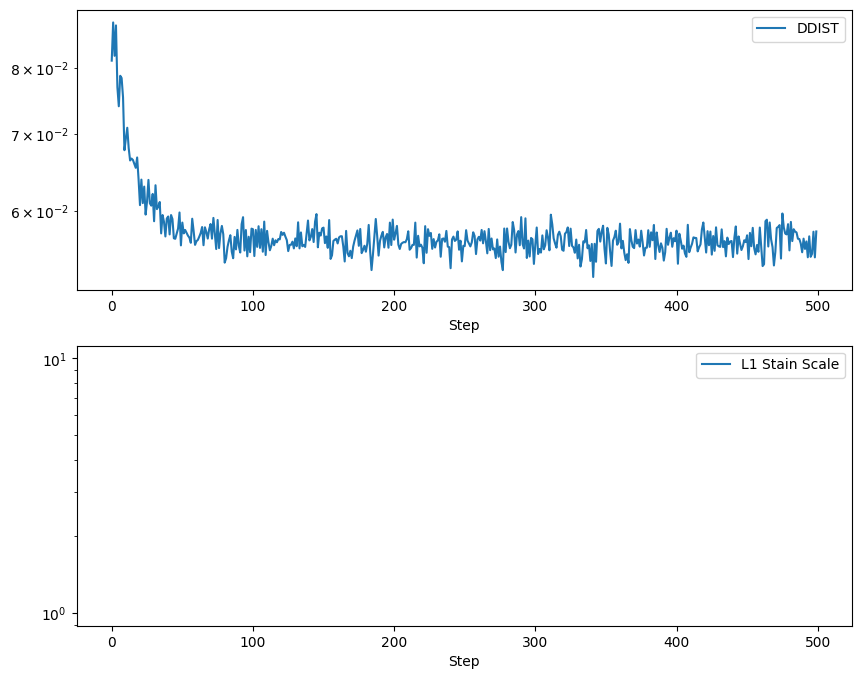

In [17]:
sfm = cytovanni.ref.OverlapFitModel.from_data(moe, transformer, dataset, DDIST_mode="sinkhorn", DDIST_kwargs={"blur":.5, "reach":1.}, DDIST_separate=False).to(device)
sfm.fit(Niter=500, lr=2e-1, momentum=.7, optimizer="SGD")
sfm.plot_losshistory()
plt.show()

While a stable loss is a necessary indicator that the fit has converged, it is a good idea to also verify that all internal parameters of the model no longer change:

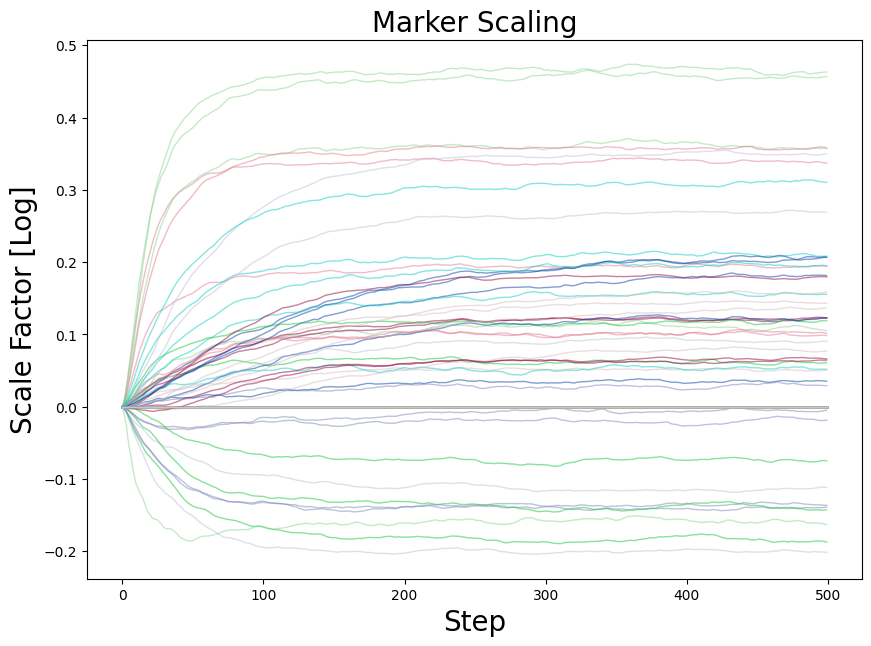

In [18]:
sfm.transformer.plot_logscale_history()

As we anchored the integration to batch 'RF_12_11_2021', all of its scaling factors are one, as well as all factors for the markers we are not integrating:

In [19]:
sfm.transformer.learned_stainscale

,BV421,BV510,BV605,BV711,BV750,BV786,BB515,BB700,BUV396,BUV496,...,BUV615,BUV661,BUV805,APC,APC-R700,APC-H7,BYG584,PE-CF594,BYG670,BYG790
RF_12_11_2021,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,...,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
RF_15_11_2021,1.0,1.063425,1.109880,1.0,1.0,1.0,1.153589,1.0,1.130648,1.0,...,1.0,1.0,1.213814,1.229907,0.817428,0.981486,1.0,1.0,1.231566,1.0
RF_16_11_2021,1.0,0.829294,0.849199,1.0,1.0,1.0,1.052203,1.0,1.130498,1.0,...,1.0,1.0,1.400469,1.035547,0.894202,0.870768,1.0,1.0,1.052690,1.0
RF_18_11_2021,1.0,0.867113,1.428804,1.0,1.0,1.0,1.079774,1.0,1.068223,1.0,...,1.0,1.0,1.102910,1.198691,1.420043,0.872543,1.0,1.0,1.167984,1.0
RF_22_11_2021,1.0,1.126528,1.578307,1.0,1.0,1.0,1.171647,1.0,1.196935,1.0,...,1.0,1.0,1.429319,1.130882,1.095050,0.995426,1.0,1.0,1.364101,1.0
RF_23_11_2021,1.0,0.927952,1.588141,1.0,1.0,1.0,1.146927,1.0,1.066734,1.0,...,1.0,1.0,1.105783,1.229141,1.308837,1.029431,1.0,1.0,1.214856,1.0


We then save the trained model.

In [21]:
sfm.save(os.path.join(data_path, "ref", "standardisation_model.pt"))

In this case, we apply the Skinhorn loss across all markers that should be scaled simulatenously. In some cases it may be necessary to instead fit every single marker separately to obtain reasonable results; this can be enabled by setting DDIST_separate to True, but will take much longer to fit.

Finally, the approach above is fully general in terms of supporting partial overlap, multiple different overlapping samples etc. In simple cases such as the current dataset, where we only have one reference sample in every batch, one could also perform a simpler version of the Sinkhorn fit:

100%|██████████| 300/300 [00:53<00:00,  5.61it/s]


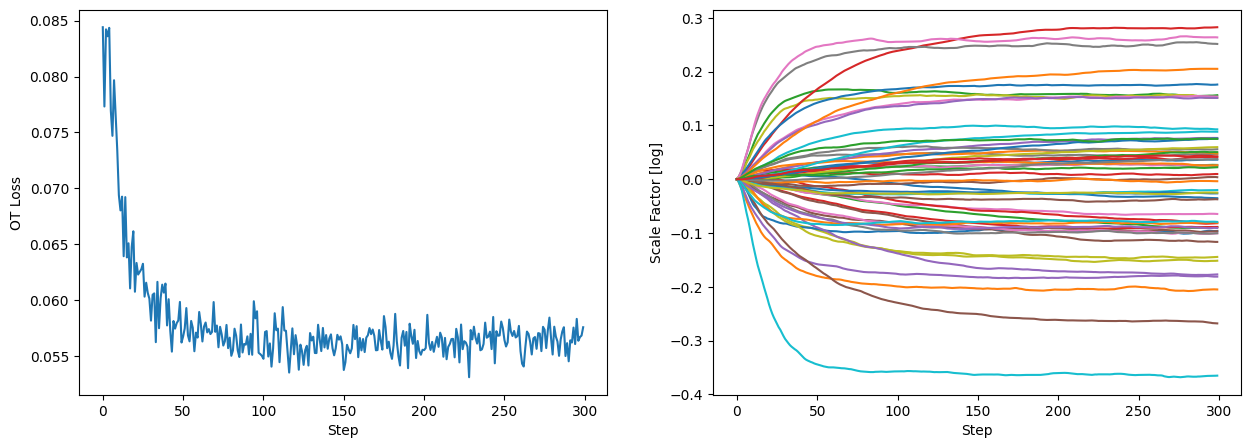

In [22]:
datadct = {ad.uns["date"]:ad.obsm["unmx"] for ad in adatas}
df_factors_separate = cytovanni.ref.fit_factors_Sinkhorn(datadct, fit_markers=markers_normalize,
                                                         arcsinh_cofactor=5000, Nsamp=2000, Niter=300, lr=2e-1, momentum=.7, device=device, verbose=True, aggregate=False, Ncomp=10,
                                                         init="null", anchor='RF_12_11_2021', dummy=False)
df_factors_separate.to_csv(os.path.join(data_path, "ref", "normalization_factors_separate.csv"))

Indeed, here both approaches yield the same scaling factors:

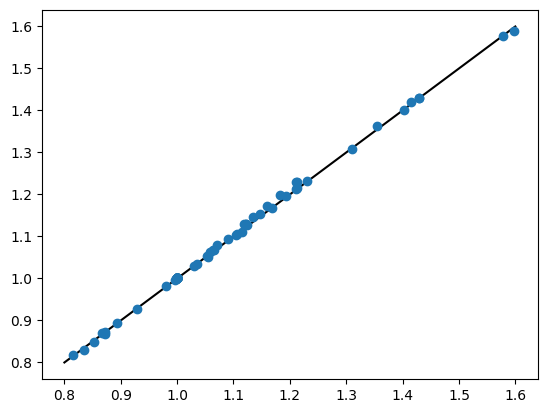

In [23]:
df_factors_sfm = sfm.transformer.learned_stainscale
plt.plot([.8,1.6],[.8,1.6], color="black", zorder=-1)
plt.scatter(df_factors_separate.loc[df_factors_sfm.index, df_factors_sfm.columns].to_numpy().flatten(),
           df_factors_sfm.to_numpy().flatten())

## Evaluate Normalization

We can load the trained model:

In [24]:
sfm = cytovanni.ref.OverlapFitModel.from_saved(os.path.join(data_path, "ref", "standardisation_model.pt"))

The model can simply add the corrected unmixed values to the adatas (which here relies on adata.uns["date"] being set to tell the model which batch a sample belongs to), adding the unmixed intensities to 'unmx_standardised':

In [25]:
for ad in adatas:
    sfm.add_ad_standardised(ad, key_layer="raw", addkey="unmx_standardised", add_arcsinh=True, arcsinh_cofactor=1500)
# collecting all batches again for simpler plotting
adata = cytovanni.utils.anndata_concat(adatas, make_unique=True, permute=True)
adata

AnnData object with n_obs × n_vars = 298276 × 27
    obs: 'Time', 'date'
    obsm: 'unmx', 'unmx_ash', 'unmx_standardised', 'unmx_standardised_arcsinh'
    layers: 'raw'

Comparing again to the raw values:

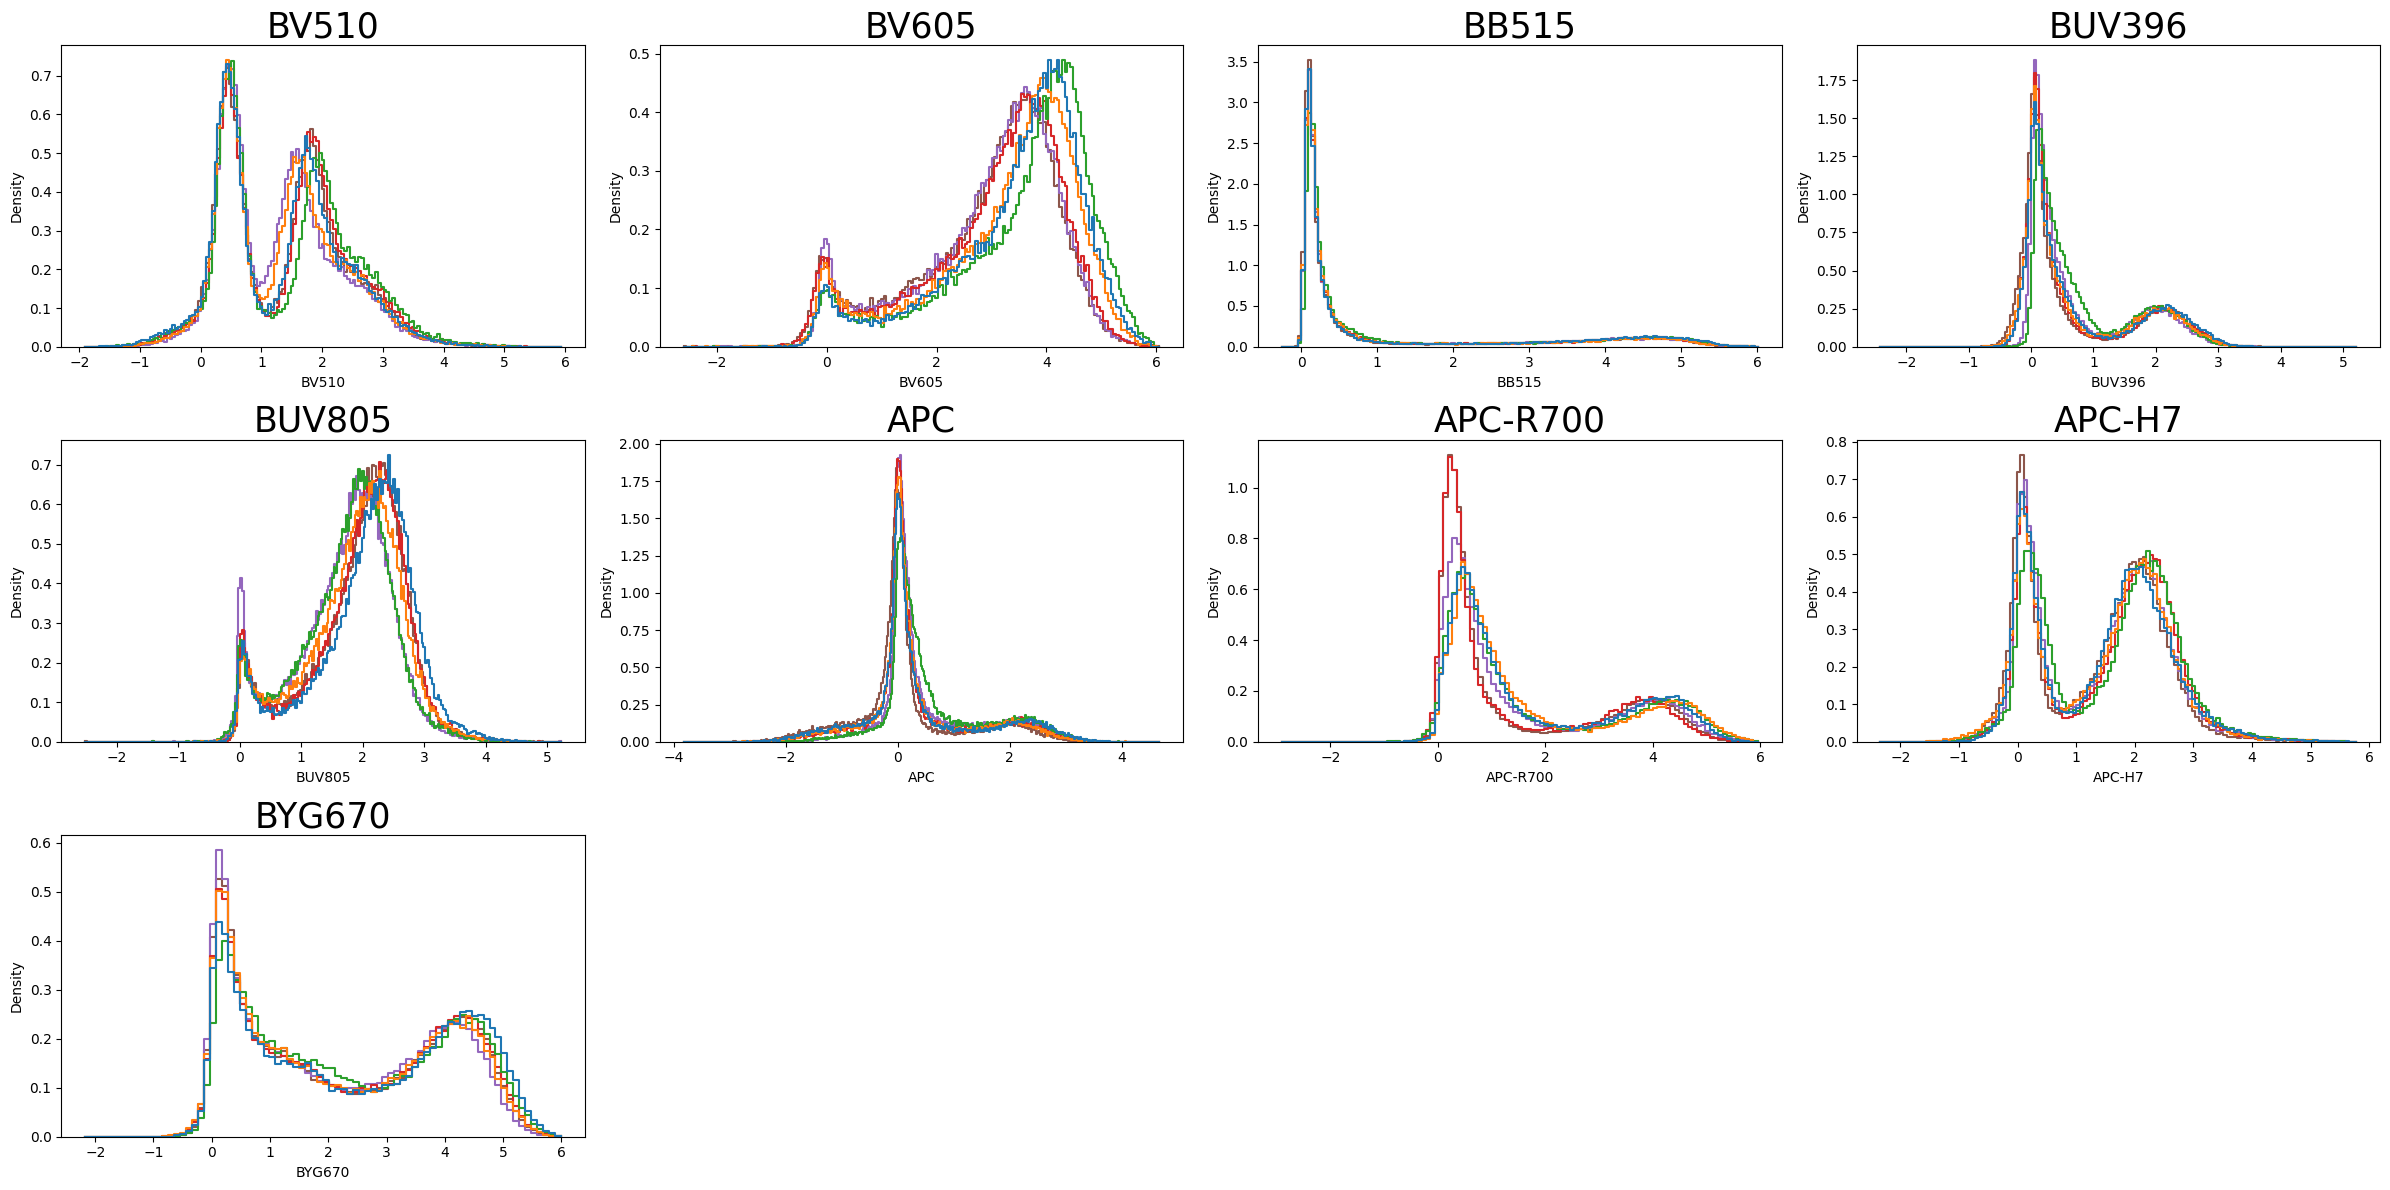

In [26]:
fig, ax = cytovanni.utils.unrolled_subplots(len(markers_normalize))
for i, key in enumerate(markers_normalize):
    sns.histplot(x=adata.obsm["unmx_ash"][key],
                 hue=adata.obs["date"], hue_order=sorted(adata.obs["date"].unique()),
                 ax=ax[i], fill=False, element="step", legend=False, stat="density", common_norm=False)
    ax[i].set_title(key, size=25)
fig.tight_layout()

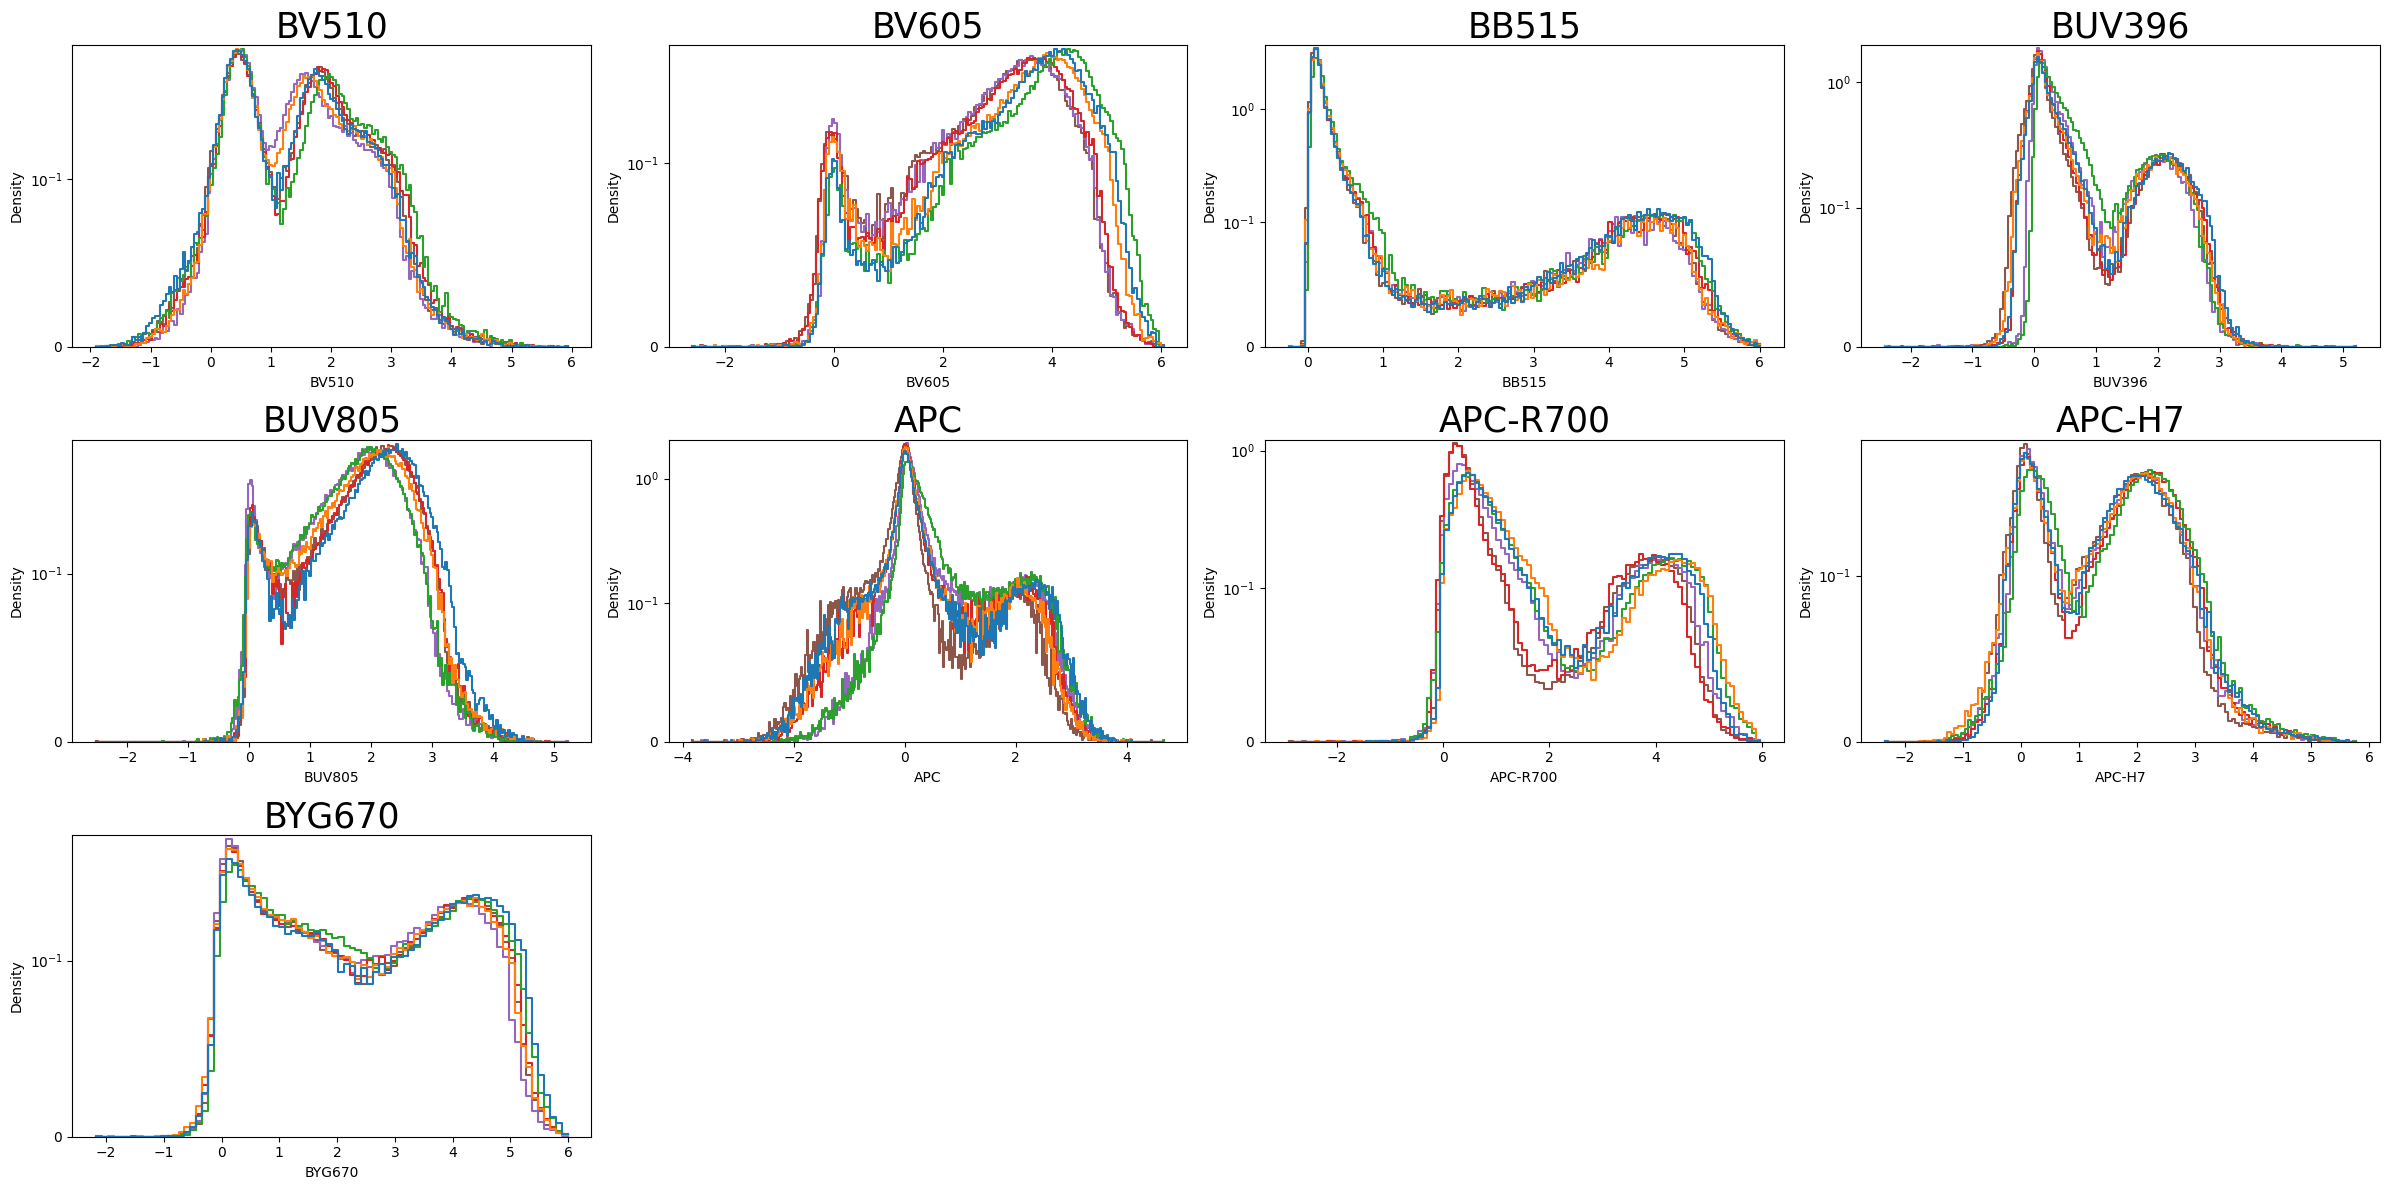

In [27]:
fig, ax = cytovanni.utils.unrolled_subplots(len(markers_normalize))
for i, key in enumerate(markers_normalize):
    sns.histplot(x=adata.obsm["unmx_ash"][key],
                 hue=adata.obs["date"], hue_order=sorted(adata.obs["date"].unique()),
                 ax=ax[i], fill=False, element="step", legend=False, stat="density", common_norm=False)
    ax[i].set_title(key, size=25)
    ax[i].set_yscale("symlog", linthresh=1e-1)
fig.tight_layout()

In contrast, after normalization using a simple scaling factor per marker, the marker histograms (at least for the positive populations) overlap almost perfectly:

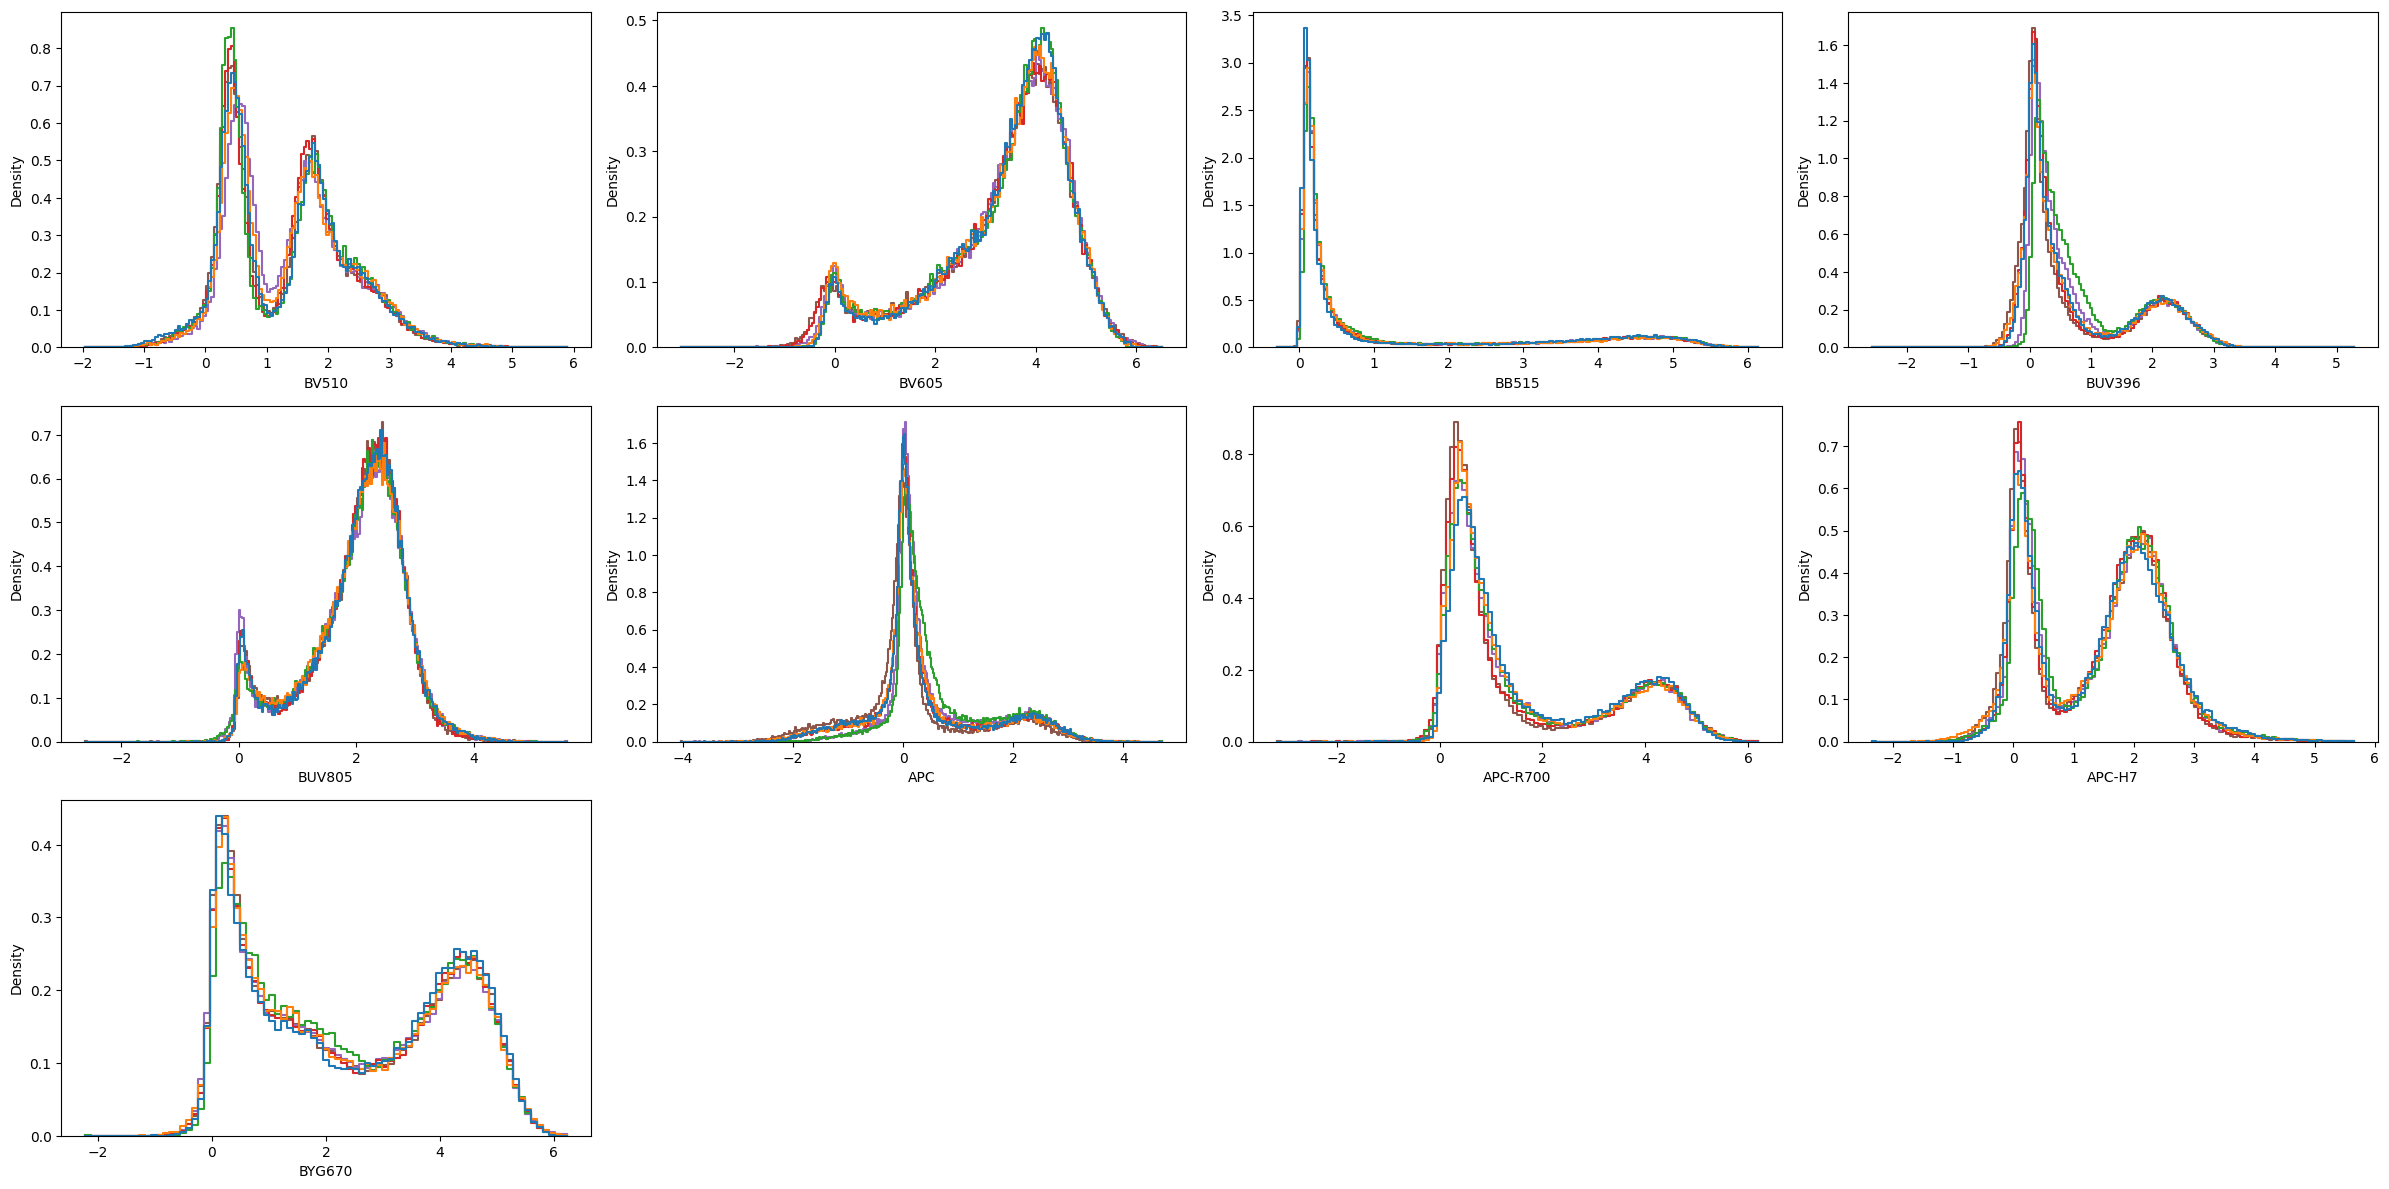

In [28]:
fig, ax = cytovanni.utils.unrolled_subplots(len(markers_normalize))
for i, key in enumerate(markers_normalize):
    sns.histplot(x=adata.obsm["unmx_standardised_arcsinh"][key],
                 hue=adata.obs["date"], hue_order=sorted(adata.obs["date"].unique()),
                 ax=ax[i], fill=False, element="step", legend=False, stat="density", common_norm=False)
fig.tight_layout()

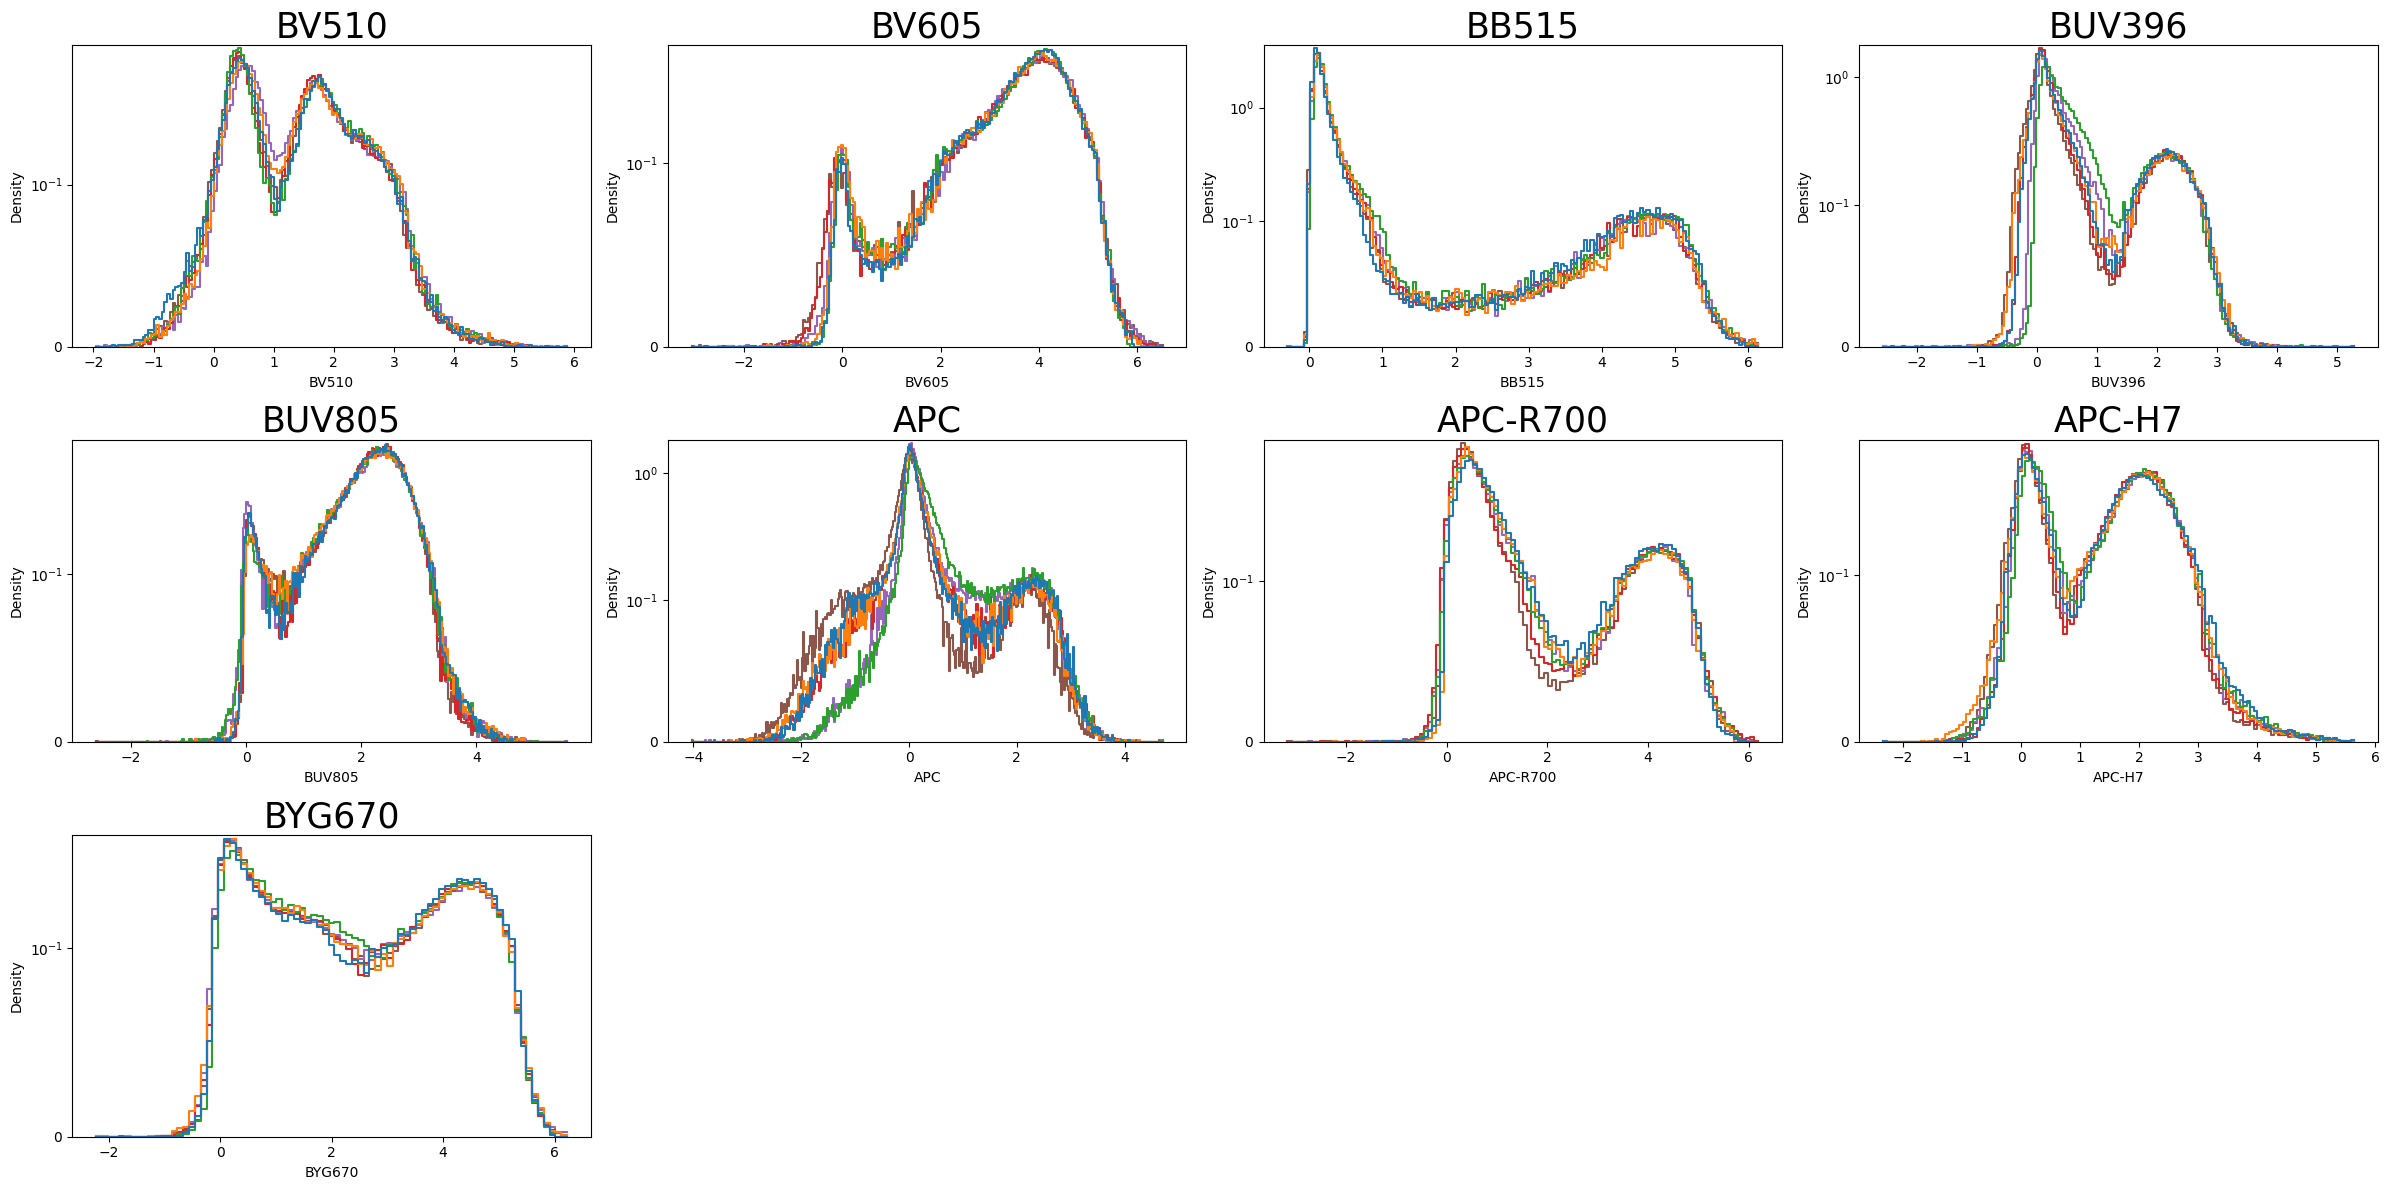

In [29]:
fig, ax = cytovanni.utils.unrolled_subplots(len(markers_normalize))
for i, key in enumerate(markers_normalize):
    sns.histplot(x=adata.obsm["unmx_standardised_arcsinh"][key],
                 hue=adata.obs["date"], hue_order=sorted(adata.obs["date"].unique()),
                 ax=ax[i], fill=False, element="step", legend=False, stat="density", common_norm=False)
    ax[i].set_title(key, size=25)
    ax[i].set_yscale("symlog", linthresh=1e-1)
fig.tight_layout()

## Export

There are different ways to use the resulting integration. It is possible to simply export the fitted scaling factors for external use:

In [30]:
df_factors_sfm = sfm.transformer.learned_stainscale
df_factors_sfm.to_csv(os.path.join(data_path, "ref", "normalization_factors.csv"))
df_factors_sfm

,BV421,BV510,BV605,BV711,BV750,BV786,BB515,BB700,BUV396,BUV496,...,BUV615,BUV661,BUV805,APC,APC-R700,APC-H7,BYG584,PE-CF594,BYG670,BYG790
RF_12_11_2021,1.0,1.000000,1.000000,1.0,1.0,1.0,1.000000,1.0,1.000000,1.0,...,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
RF_15_11_2021,1.0,1.063425,1.109880,1.0,1.0,1.0,1.153589,1.0,1.130648,1.0,...,1.0,1.0,1.213814,1.229907,0.817428,0.981486,1.0,1.0,1.231566,1.0
RF_16_11_2021,1.0,0.829294,0.849199,1.0,1.0,1.0,1.052203,1.0,1.130498,1.0,...,1.0,1.0,1.400469,1.035547,0.894202,0.870768,1.0,1.0,1.052690,1.0
RF_18_11_2021,1.0,0.867113,1.428804,1.0,1.0,1.0,1.079774,1.0,1.068223,1.0,...,1.0,1.0,1.102910,1.198691,1.420043,0.872543,1.0,1.0,1.167984,1.0
RF_22_11_2021,1.0,1.126528,1.578307,1.0,1.0,1.0,1.171647,1.0,1.196935,1.0,...,1.0,1.0,1.429319,1.130882,1.095050,0.995426,1.0,1.0,1.364101,1.0
RF_23_11_2021,1.0,0.927952,1.588141,1.0,1.0,1.0,1.146927,1.0,1.066734,1.0,...,1.0,1.0,1.105783,1.229141,1.308837,1.029431,1.0,1.0,1.214856,1.0


The model can also add the normalized unmixed values to any adata, as long as the relevant batch label, here adata.uns["date"], is set:

In [31]:
ad = adatas[1]
sfm.add_ad_standardised(ad, key_layer="raw", addkey="unmx_standardised", add_arcsinh=True, arcsinh_cofactor=1500)
ad.obsm["unmx_standardised"].head()

,BV421,BV510,BV605,BV711,BV750,BV786,BB515,BB700,BUV396,BUV496,...,BUV615,BUV661,BUV805,APC,APC-R700,APC-H7,BYG584,PE-CF594,BYG670,BYG790
0,685.718323,3003.070068,36024.160156,1401.798828,12.862928,4870.607910,91353.421875,-4443.354492,281.744507,-1506.251221,...,3834.845703,-3473.057617,4301.947266,15932.510742,47367.894531,7722.231445,10560.172852,-3528.063232,111874.570312,1534.754272
1,43.974552,6145.579590,11215.928711,2354.202881,-296.123260,4259.226562,11512.735352,-7146.915527,-268.497070,88.881454,...,4427.736816,-560.919006,6663.467773,-5708.894043,57172.550781,1127.038818,2822.978516,-2972.624756,101072.906250,1267.821167
2,144.310318,3306.261963,33291.378906,262.351349,231.554977,769.988220,187.174835,163.987076,3716.383057,936.715759,...,438.060303,-654.816345,5807.801270,631.950562,383.699860,14280.656250,960.612671,420.152649,5437.154785,2007.658936
3,3158.857666,30533.886719,27925.980469,1022.200439,1996.749146,2313.894043,3233.437012,-109.819862,6321.908203,3327.726318,...,16772.041016,121.052475,15900.366211,-136.067230,20991.208984,41490.148438,5197.367188,-12.745560,10614.866211,1329.928589
4,438.918579,8489.386719,576.944580,123.544716,116.329208,284.506348,428.798401,125.630722,247.234818,-687.425842,...,643.070374,168.549133,2594.643066,49.804996,748.666992,638.181519,1272.282715,50.672501,251.555481,62.287571


It is also possible to extract all other parameters from the model:

In [36]:
stainscale, spectra, unmx_norm_matrix = sfm.transformer.get_standardisationparams_fromad(ad)

This includes the normalization factors:

In [33]:
stainscale.head()

BV421    1.000000
BV510    1.063425
BV605    1.109880
BV711    1.000000
BV750    1.000000
dtype: float32

The dye spectra:

In [34]:
spectra.head()

,BV421,BV510,BV605,BV711,BV750,BV786,BB515,BB700,BUV396,BUV496,...,BUV615,BUV661,BUV805,APC,APC-R700,APC-H7,BYG584,PE-CF594,BYG670,BYG790
BV421-A,1.000000,0.056361,0.025210,0.059129,0.044053,0.052704,0.000089,0.000000,0.001805,0.007090,...,0.000706,0.000565,0.003774,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BV510-A,0.295913,1.000000,0.007012,0.017990,0.015624,0.018304,0.141048,0.011604,0.000639,0.283197,...,0.000429,0.000732,0.003223,0.000000,0.000100,0.000000,0.003504,0.000078,0.000000,0.000000
BV605-A,0.013960,0.162141,1.000000,0.001844,0.003252,0.002874,0.013399,0.028766,0.000000,0.022571,...,0.086652,0.004259,0.000590,0.001814,0.000184,0.000000,0.108003,0.204459,0.006869,0.001339
BV711-A,0.001465,0.010183,0.144825,1.000000,0.246495,0.018962,0.000922,0.309808,0.000000,0.001637,...,0.010897,0.031829,0.000300,0.038141,0.031201,0.000851,0.007460,0.026722,0.036961,0.001890
BV750-A,0.000513,0.002983,0.040942,0.365883,1.000000,0.283279,0.000525,0.086060,0.000058,0.000357,...,0.002704,0.008200,0.002035,0.013716,0.015030,0.016572,0.001479,0.006238,0.010770,0.041239


As well as a matrix for the corresponding batch that handles both the unmixing and the marker rescaling:

In [37]:
(ad.to_df("raw")[unmx_norm_matrix.index] @ unmx_norm_matrix).head()

,BV421,BV510,BV605,BV711,BV750,BV786,BB515,BB700,BUV396,BUV496,...,BUV615,BUV661,BUV805,APC,APC-R700,APC-H7,BYG584,PE-CF594,BYG670,BYG790
0,685.717944,3003.069199,36024.156721,1401.795770,12.862439,4870.607892,91353.420215,-4443.360459,281.744115,-1506.251037,...,3834.845395,-3473.059685,4301.946617,15932.506892,47367.895215,7722.234007,10560.173604,-3528.061675,111874.574743,1534.752869
1,43.974305,6145.578025,11215.927677,2354.200852,-296.123869,4259.225470,11512.734148,-7146.923964,-268.497475,88.881601,...,4427.736829,-560.919281,6663.467277,-5708.890518,57172.554083,1127.043603,2822.978856,-2972.623754,101072.905105,1267.820239
2,144.310189,3306.261385,33291.374199,262.350765,231.554907,769.987337,187.174853,163.985929,3716.381825,936.715876,...,438.059436,-654.816906,5807.801751,631.951120,383.699926,14280.654946,960.612598,420.152756,5437.153239,2007.659023
3,3158.856761,30533.883726,27925.974288,1022.199237,1996.748581,2313.891568,3233.437109,-109.818031,6321.906880,3327.725632,...,16772.041070,121.052440,15900.364425,-136.066774,20991.209869,41490.144899,5197.367662,-12.743505,10614.865067,1329.927751
4,438.918490,8489.385038,576.944293,123.544682,116.329194,284.506076,428.798423,125.630607,247.234537,-687.426061,...,643.070294,168.549130,2594.643099,49.805005,748.667072,638.181416,1272.282837,50.672608,251.555474,62.287570
